In [2]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from seq_models import (
    SeqDataset, collate_fn,
    LSTMClassifier, TransformerClassifier,
    train, evaluate
)

warnings.filterwarnings("ignore")

## Датасет [Diabets](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [3]:
import kagglehub

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database") + "/diabetes.csv"

df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
le = LabelEncoder()
y = le.fit_transform(y)
labels = y.tolist()

In [5]:
categorical_features = []
numerical_features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
scaler = StandardScaler()
X_numerical = scaler.fit_transform(X[numerical_features])

X_combined = X_numerical

X_seqs = [row.reshape(len(row), 1) for row in X_combined]
train_data, test_data, train_labels, test_labels = train_test_split(X_seqs, labels, test_size=0.2, random_state=0, stratify=y, shuffle=True)
test_data, valid_data, test_labels, valid_labels = train_test_split(test_data, test_labels, test_size=0.5, random_state=0, stratify=test_labels, shuffle=True)

In [6]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


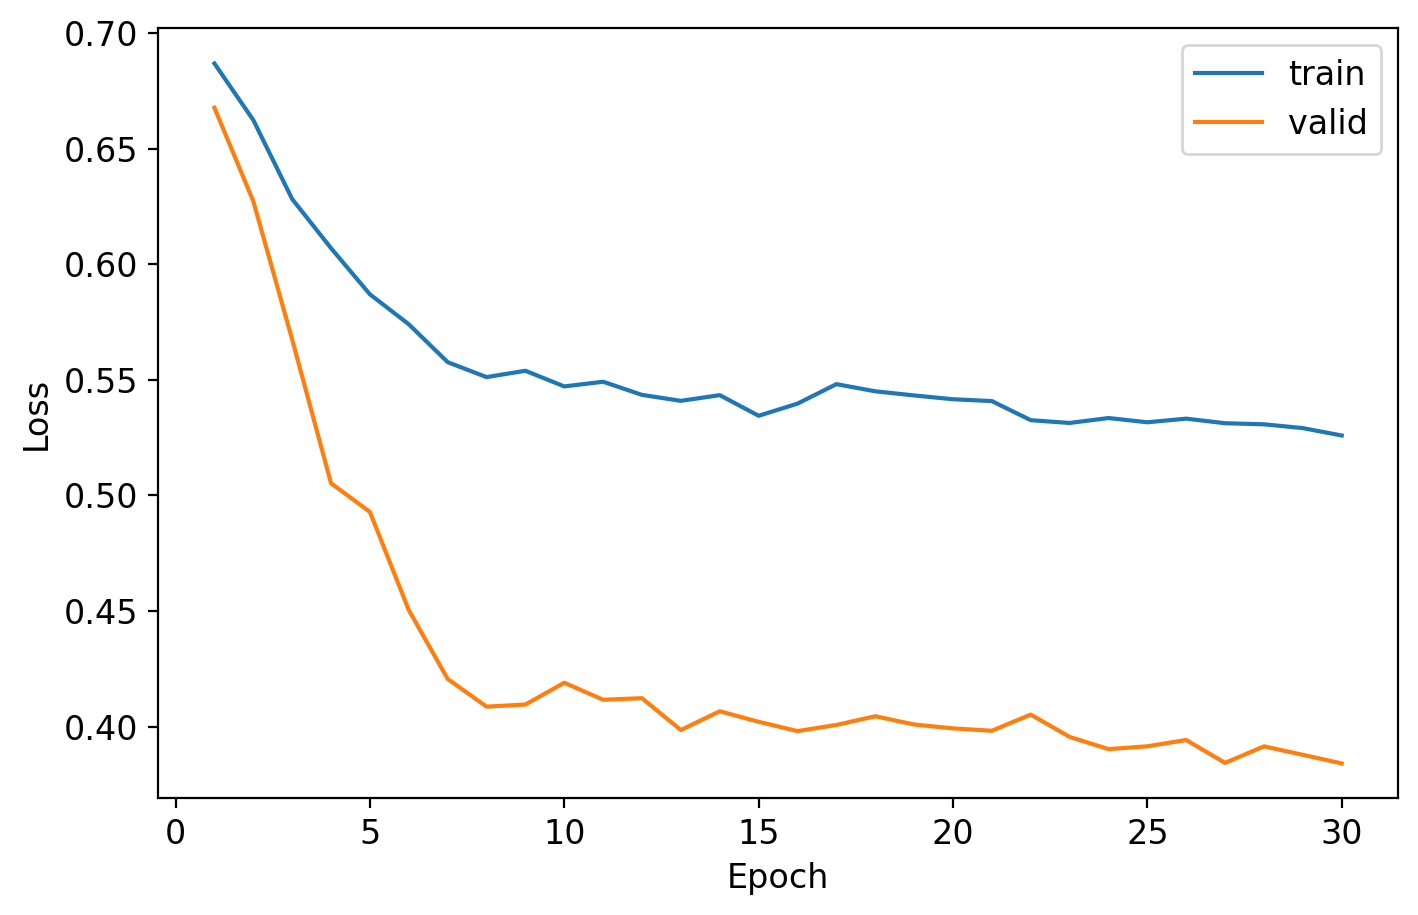

Epoch 30: train loss = 0.5259; valid loss = 0.3840


In [16]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 30, train_loader, valid_loader, criterion, device, scheduler=None)

In [17]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.7319
F1 = 0.4651
Accuracy = 0.7013
Precision = 0.6250
Recall = 0.3704


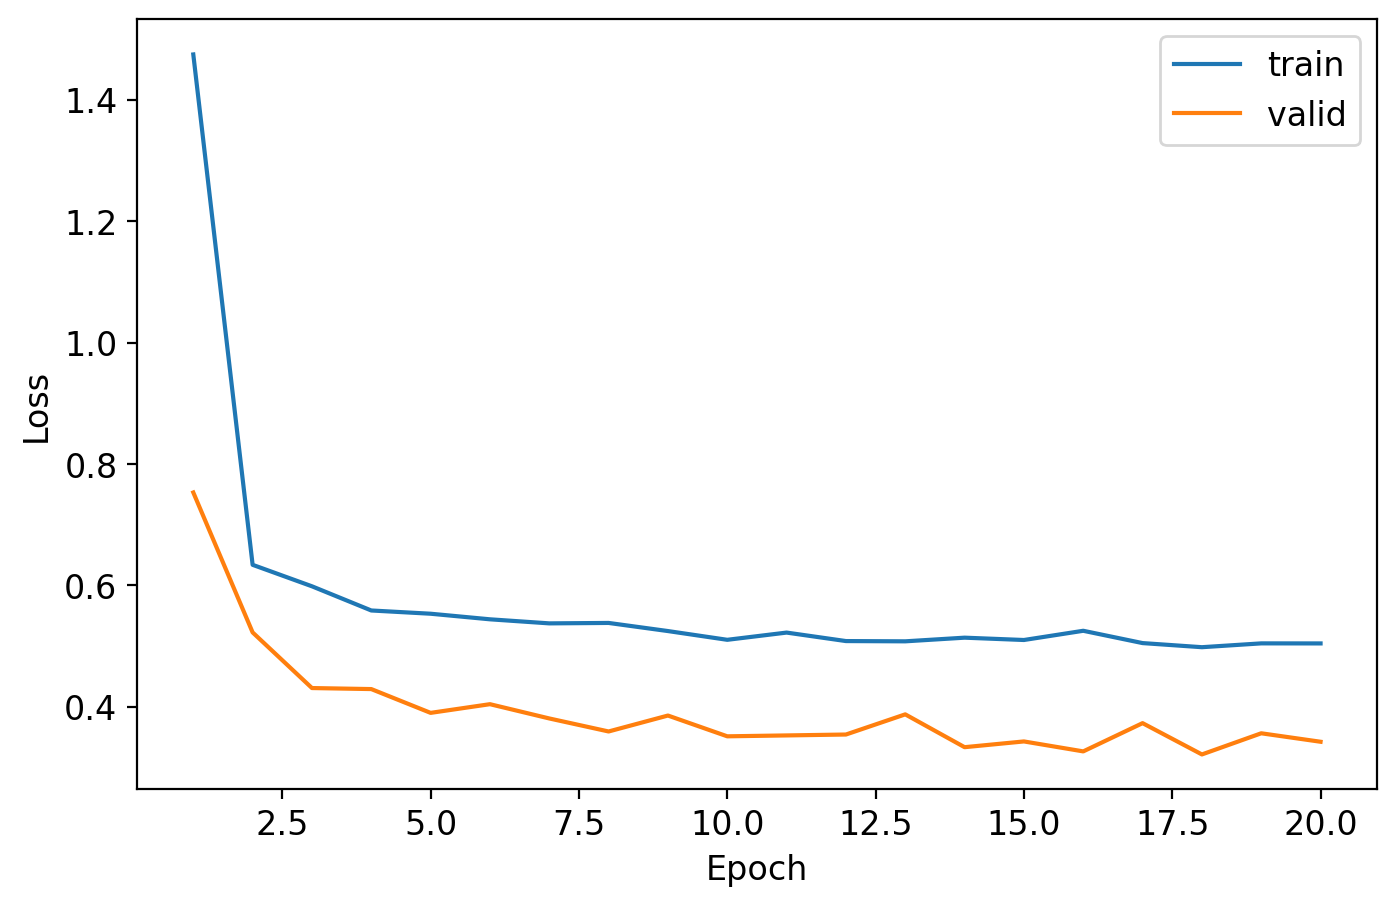

Epoch 20: train loss = 0.5043; valid loss = 0.3423


In [22]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [23]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.7970
F1 = 0.4737
Accuracy = 0.7403
Precision = 0.8182
Recall = 0.3333
